# Study area selection

*SPDX-FileCopyrightText: © 2026 Nina Preußler <nina.preussler@studserv.uni-leipzig.de>*

*SPDX-License-Identifier: CC BY 4.0*

This notebook contains the code for selecting the study area for the Random Forest analysis of factors influencing post-fire vegetation recovery in tropical peat forests in Indonesia. With the island of Kalimantan as the general study area, in this notebook we identify the specific pixels for which we want to analyze recovery. This selection is composed of the following steps:
1. [Delimit geographic boundaries](#Geographic-boundaries)
2. [Use MODIS fire alerts to identify study period](#MODIS-fire-alerts)
3. [Load burned area](#Burned-area)
4. [Filter for peatland area](#Peatlands)
5. [Remove area that burned again](#Burned-again)
6. [Filter for area that was forest pre-fire](#Forest-2015)
7. [Remove area that was converted to cropland](#Cropland-2021)

At the end, a TIFF file with the pixels used for our investigation is exported

In [48]:
# General settings and important variables
equal_area_proj = 'EPSG:8857' # Equal Earth

# defined start and end of fire season we investigate
start_date = '2015-08-01'
end_date = '2015-10-31'

In [49]:
from rasterio.enums import Resampling

In [50]:
# load custom function from custom_functions.py
from custom_functions import sel_bounds 

# Geographic boundaries

In [51]:
import cartopy.io.shapereader as shpreader
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon

In [52]:
# import country borders using natural earth data
shpfilename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_0_countries')
world = gpd.read_file(shpfilename)

# select only Indonesia
indonesia = world[world['NAME'] == 'Indonesia']

# export
indonesia.to_file('output-data/borders/indonesia.shp')

In [53]:
# extract islands

# split MultiPolygon into individual polygons
islands = indonesia.explode(index_parts=True).reset_index(drop=True)

# add area (in degrees² — good enough for sorting/filtering)
islands['area'] = islands.geometry.area

# sort by area descending
islands_sorted = islands.sort_values('area', ascending=False).reset_index(drop=True)

# extract by rank
kalimantan = islands_sorted.iloc[[0]]
sumatra = islands_sorted.iloc[[1]]
papua = islands_sorted.iloc[[2]]

# export
kalimantan.to_file('output-data/borders/kalimantan.shp')
sumatra.to_file('output-data/borders/sumatra.shp')
papua.to_file('output-data/borders/papua.shp')


/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_11378/774798125.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  islands['area'] = islands.geometry.area


<Axes: >

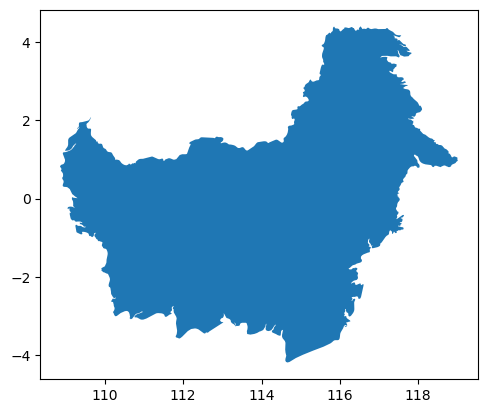

In [54]:
kalimantan.plot()

In [55]:
# get bounding box coordinates
indonesia.bounds

,minx,miny,maxx,maxy
0,95.012706,-10.922621,140.977627,5.910102


# MODIS fire alerts 
from NASA FIRMS

Indonesia, 2001 to 2025

attribute documentation [here](https://www.earthdata.nasa.gov/data/tools/firms/active-fire-data-attributes-modis-viirs)

$\rightarrow$ used to identify study period (which fire season) and as influencing factor (fire history)

In [56]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [57]:
# read as geopandas dataframe
modis_fa_path = "input-data/nasa-firms-modis-fire-alerts/fire_archive_M-C61_697841.shp"
modis_fa = gpd.read_file(modis_fa_path)

In [58]:
# filter to only keep TYPE 0 (presumed vegetation fire, not volcano activity etc.)
modis_fa_vf = modis_fa[modis_fa["TYPE"] == 0].copy()

In [59]:
# add column with year and month (as integers)
modis_fa_vf.loc[:,"YEAR"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=1).str[0].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

modis_fa_vf.loc[:,"MONTH"] = modis_fa_vf["ACQ_DATE"].astype("str").str.split(pat="-", n=2).str[1].astype("int32")
modis_fa_vf = modis_fa_vf.astype({'YEAR': 'int32'})

In [60]:
modis_fa_vf.head()

,LATITUDE,LONGITUDE,BRIGHTNESS,SCAN,TRACK,ACQ_DATE,ACQ_TIME,SATELLITE,INSTRUMENT,CONFIDENCE,VERSION,BRIGHT_T31,FRP,DAYNIGHT,TYPE,geometry,YEAR,MONTH
0,-4.0082,121.7859,312.0,2.3,1.5,2001-01-01,0258,Terra,MODIS,57,6.03,291.7,22.9,D,0,POINT (121.7859 -4.0082),2001,1
1,-8.4164,117.5434,320.0,1.3,1.1,2001-01-01,0259,Terra,MODIS,39,6.03,305.8,13.1,D,0,POINT (117.5434 -8.4164),2001,1
5,-8.8759,120.7638,314.9,2.6,1.6,2001-01-02,0204,Terra,MODIS,0,6.03,296.0,28.8,D,0,POINT (120.7638 -8.8759),2001,1
8,-8.2273,123.8952,312.5,2.2,1.4,2001-01-03,0247,Terra,MODIS,0,6.03,286.4,17.1,D,0,POINT (123.8952 -8.2273),2001,1
13,0.0546,101.7350,312.4,1.5,1.2,2001-01-05,0411,Terra,MODIS,60,6.03,284.5,12.7,D,0,POINT (101.735 0.0546),2001,1


Number of fire pixels in 2015: 2810394


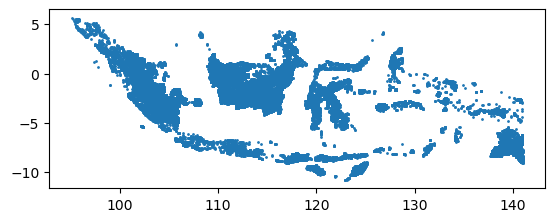

In [61]:
# plot fires in 2015
modis_fa_vf_2015 = modis_fa_vf[modis_fa_vf["YEAR"] == 2015]

print("Number of fire pixels in 2015:", end=' ')
print(modis_fa_vf_2015.size)

modis_fa_vf_2015.plot(markersize=1)
plt.show()

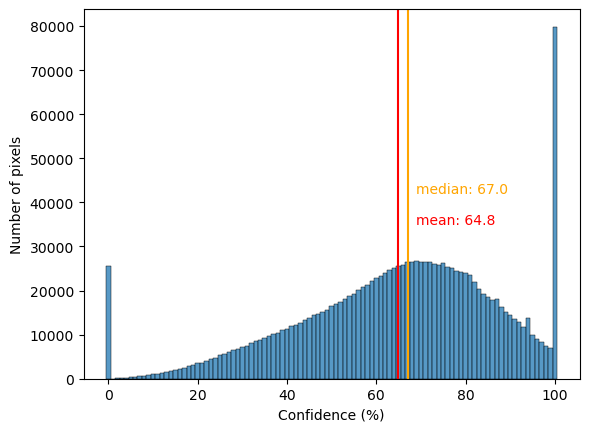

In [62]:
# check distribution of confidence
sns.histplot(x="CONFIDENCE", data=modis_fa_vf, discrete=True)
plt.ylabel("Number of pixels")
plt.xlabel("Confidence (%)")

# add mean confidence
mean_conf = modis_fa_vf.CONFIDENCE.mean()
plt.axvline(mean_conf, color="red")
plt.text(x=mean_conf+4, y=35000, s=f"mean: {round(mean_conf,1)}", color="red")

# add median confidence
med_conf = np.median(modis_fa_vf.CONFIDENCE)
plt.axvline(med_conf, color="orange")
plt.text(x=mean_conf+4, y=42000, s=f"median: {round(med_conf,1)}", color="orange")

plt.show()

In [63]:
np.std(modis_fa_vf.CONFIDENCE)

22.252626195361497

In [64]:
# add boolean column with confidence classification based on defined threshold
confidence_threshold = 70
modis_fa_vf['HIGH_CONFIDENCE'] = np.where(modis_fa_vf['CONFIDENCE'] >= confidence_threshold, True, False)

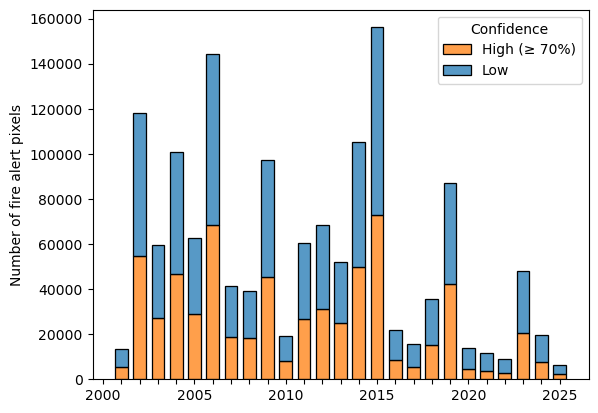

In [65]:
# check nr of fires per year
sns.histplot(x="YEAR", 
             hue="HIGH_CONFIDENCE", multiple="stack", 
             legend=False,
             data=modis_fa_vf,
             discrete=True,
             shrink=.7)

# adjust xticks
values = np.arange(2000,2026,1)
labels = np.arange(2000,2026,1)[::5] # only every fifth
labels = np.where(np.isin(values, labels), values, "")
plt.xticks(values, labels=labels)

plt.xlabel("")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

$\rightarrow$ 2015 was the year with the most fire alerts

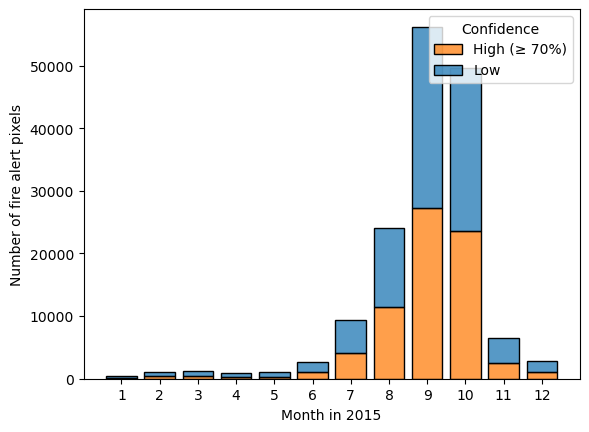

In [66]:
# check fires per month in 2015
modis_fa_2015 = modis_fa_vf[modis_fa_vf.YEAR == 2015]

sns.histplot(x="MONTH", 
             hue="HIGH_CONFIDENCE",
             multiple="stack", discrete=True,
             legend=False,
             shrink=.8,
             data=modis_fa_2015)

plt.xticks(np.arange(1,13,1))

plt.xlabel("Month in 2015")
plt.ylabel("Number of fire alert pixels")

plt.legend(title='Confidence', loc='upper right', labels=[f'High (≥ {confidence_threshold}%)', 'Low'])

plt.show()

most fires from August to October $\rightarrow$ investigate recovery from fires in this time interval

In [67]:
# keep only relevant columns
modis_fa_vf = modis_fa_vf[['LATITUDE', 'LONGITUDE', 'ACQ_DATE', 'CONFIDENCE', 'geometry', 'HIGH_CONFIDENCE']]

In [68]:
# subset to before, during, and after fire detection period (high confidence only)
# lower confidence threshold for after 2015 to make sure to exclude pixels with repeated burns

fires_before = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= confidence_threshold) & (modis_fa_vf.ACQ_DATE < start_date)]
fires_summer_2015 = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= confidence_threshold) & (modis_fa_vf.ACQ_DATE.between(start_date,end_date))]
fires_after = modis_fa_vf[(modis_fa_vf.CONFIDENCE >= 30) & (modis_fa_vf.ACQ_DATE > end_date) & (modis_fa_vf.ACQ_DATE < '2022-01-01')]

In [69]:
# export 
fires_before.to_file('output-data/fire-alerts/fire_alerts_before.shp')
fires_after.to_file('output-data/fire-alerts/fire_alerts_after.shp')
fires_summer_2015.to_file('output-data/fire-alerts/fire_alerts_summer_2015.shp')

/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_11378/485468498.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  fires_before.to_file('output-data/fire-alerts/fire_alerts_before.shp')
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ACQ_DATE created as String field, though DateTime requested.
  ogr_write(
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'HIGH_CONFIDENCE' to 'HIGH_CONFI'
  ogr_write(
/var/folders/fr/fhx_52c5115d__lt3q_fsf2r0000gn/T/ipykernel_11378/485468498.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  fires_after.to_file('output-data/fire-alerts/fire_alerts_after.shp')
/Users/ninap/anaconda3/envs/rsapp_peat/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ACQ_DATE created

continued in [here](#Fire-history)

# Burned area

created with GEE (see script)
from https://developers.google.com/earth-engine/datasets/catalog/ESA_CCI_FireCCI_5_1

In [70]:
import rioxarray as rxr
import rasterio 
import numpy as np
from shapely.geometry import mapping

In [71]:
# load file
filepath_ba = "input-data/burned-area/burned-area-aug-to-oct-2015.tif"
burned_area = rxr.open_rasterio(filepath_ba)

In [72]:
# split by islands
burned_area_kalimantan = sel_bounds(burned_area, kalimantan)

$\rightarrow$ this burned area raster (EPSG 4326 and 250m resolution) will serve as the reference raster that all other rasters will be reprojected to and aligned with

# Peatlands

from Global Peatlands

In [73]:
import rioxarray as rxr
import xarray as xr
import rasterio 
import numpy as np

In [74]:
# load data as xarray
filepath_gp = "input-data/global-peatland-map/peatGPA22WGS_2cl.tif"
peatland = rxr.open_rasterio(filepath_gp)

# set CRS
peatland.rio.write_crs(4326, inplace=True)

# subset to Indonesia
peatland = sel_bounds(peatland, indonesia)

In [75]:
# set 255 (no peatland) and 2 (peat in soil matrix) to NaN
peatland = peatland.where(peatland == 1, other=0).astype('uint8')

# set no-data value
# peatland = peatland.rio.write_nodata(0, encoded=True)

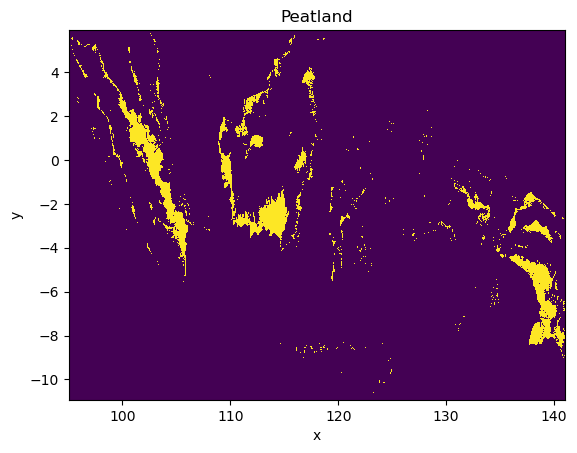

In [76]:
peatland.plot(add_colorbar=False)
plt.title('Peatland')
plt.show()

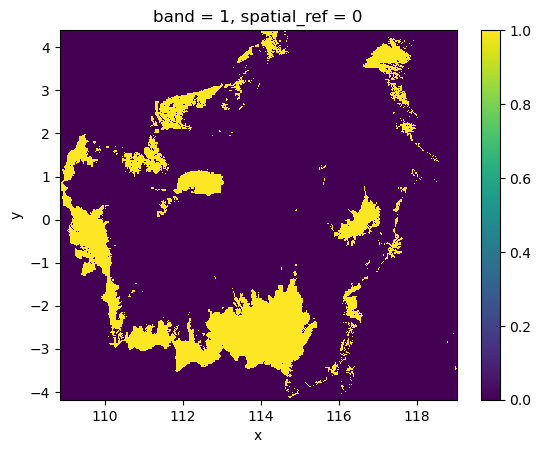

In [77]:
# select islands
peatland_kalimantan = sel_bounds(peatland, burned_area_kalimantan)
peatland_kalimantan.plot()
plt.show()

In [78]:
# reproject to match burned area projection/resolution/grid
peatland_kalimantan_reproj = peatland_kalimantan.rio.reproject_match(
    burned_area_kalimantan, 
    resampling=Resampling.nearest) # downscaling (1km -> 250m) -> inherit value of larger pixel

# replace resulting 255 values
peatland_kalimantan_reproj = peatland_kalimantan_reproj.where(peatland_kalimantan_reproj != 255, 0).rio.write_crs(4326)

In [79]:
# export as tif and NetCDF
peatland_kalimantan_reproj.rio.to_raster('output-data/peatland/peatland_kalimantan.tif')

In [80]:
# merge both arrays
merged_kalimantan = xr.merge([burned_area_kalimantan.rename('burned_area'),
                              peatland_kalimantan_reproj.rename('peatland')],
                             compat='no_conflicts')

# set up layer that will identify the study area
merged_kalimantan['study_area'] = xr.where(
    (merged_kalimantan.burned_area == 1) & (merged_kalimantan.peatland == 1), # only areas in peatlands that burned
    1, 0).astype('uint8')

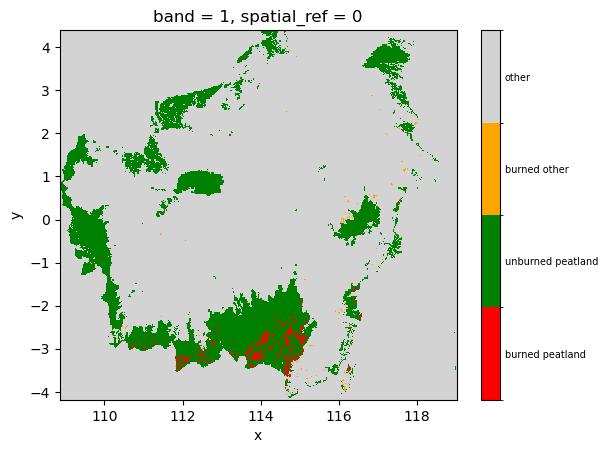

In [81]:
# check where burned area and peatlands overlap

# create array with categories
categories = ['burned peatland', 'unburned peatland', 'burned other', 'other']
burned_peat_categories = xr.where((merged_kalimantan.burned_area == 1) & (merged_kalimantan.peatland == 1), 
                                   1, 
                                   xr.where((merged_kalimantan.burned_area == 0) & (merged_kalimantan.peatland == 1),
                                            2,
                                            xr.where((merged_kalimantan.burned_area == 1) & (merged_kalimantan.peatland != 1),
                                                     3,
                                                     4
                                                     )))

# set up labels and colors
levels = [1,2,3,4]
levels += [levels[-1] + 1]
colors = ['red','green','orange','lightgrey']
labels = categories

# plot classification as a map with a colormap
plt.figure()
ax = burned_peat_categories.plot(levels=levels, colors=colors)

# Compute position of ticks for labeling of colormap
tick_positions = np.mean([levels[:-1], levels[1:]], axis=0)

# Set labels at the middle of each color block in colormap legend 
ax.colorbar.set_ticks(tick_positions)  # define ticks for label position
ax.colorbar.ax.tick_params(length=0)  # hides ticks, so only labels are shown
ax.colorbar.set_ticklabels(labels, fontsize=7) # labels positiond to corresponding color

plt.show()

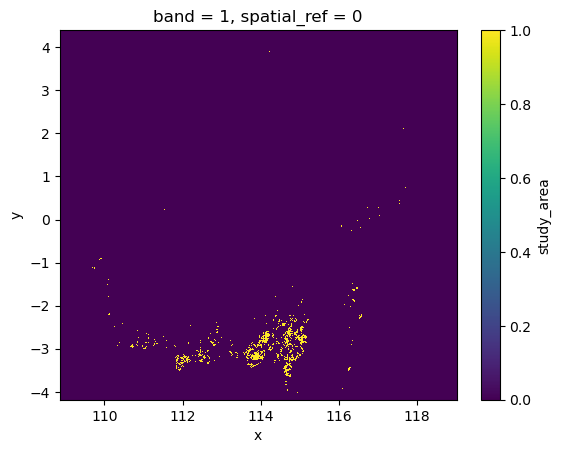

In [82]:
merged_kalimantan.study_area.plot()

# Burned again

In [83]:
# Next, rasterize fire alerts with buffer, since points represent centroid of 1km2 pixel that contained fire

# Project to metric CRS (e.g. World Mercator)
fires_proj = fires_after.to_crs("EPSG:3857")

# Buffer 500 meters
fires_proj["geometry"] = fires_proj.buffer(500, cap_style='square') # add 500m buffer

# to target CRS
fires_buffered = fires_proj.to_crs(merged_kalimantan.rio.crs)

# rasterize to existing study area grid

from rasterio import features

transform = merged_kalimantan.rio.transform()
out_shape = merged_kalimantan.rio.shape

shapes = ((geom, 1) for geom in fires_buffered.geometry)

# binary classification
reburn_binary = features.rasterize(
    shapes=shapes,
    out_shape=out_shape,
    transform=transform,
    all_touched=True,
    dtype="uint8"
)

In [84]:
# add to merged ds
merged_kalimantan["burned_again"] = xr.DataArray(
    reburn_binary,
    dims=["y", "x"],
    coords={"y": merged_kalimantan.y, "x": merged_kalimantan.x},
)

In [85]:
# update study area (only keep pixels that did not burn again)
merged_kalimantan['study_area'] = xr.where((merged_kalimantan.study_area == 1) & (merged_kalimantan.burned_again == 1),
                                           0, # set to 0 if previously study area but burned again
                                           merged_kalimantan.study_area) # leave remaining pixels as they are

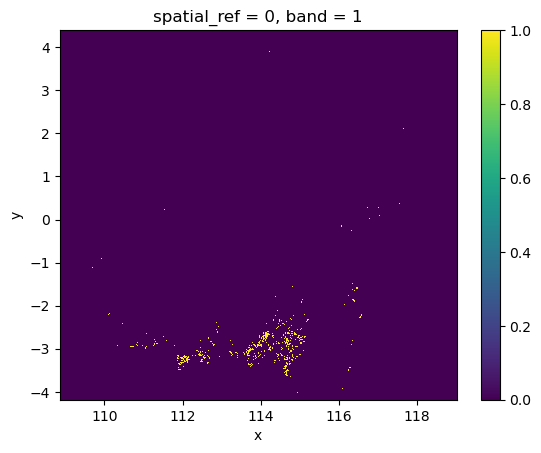

In [86]:
xr.where((merged_kalimantan.burned_again == 0) & (merged_kalimantan.study_area == 1), 1, 0).plot()

# Forest 2015

from Global Landcover map 2015 by Li et al. (2023)

used to identify forest peatland (we only want to study vegetation recovery in burned forest)

In [87]:
import xarray as xr
import rioxarray as rxr
import numpy as np
import os
from rioxarray.merge import merge_arrays
import geopandas as gpd

In [88]:
# build virtual raster (VRT)
!gdalbuildvrt input-data/land-cover/landcover_2015_30m.vrt $(find input-data/land-cover -name "*.tif")

0...10...20...30...40...50...60...70...80...90...100 - done.


In [89]:
# load VRT
land_cover_2015 = rxr.open_rasterio('input-data/land-cover/landcover_2015_30m.vrt')

# set CRS
peatland.rio.write_crs(4326, inplace=True)

# crop to island
land_cover_2015_kalimantan = sel_bounds(land_cover_2015, burned_area_kalimantan)

# reproject
land_cover_2015_kalimantan_reproj = land_cover_2015_kalimantan.rio.reproject_match(
    burned_area_kalimantan,
    resampling=Resampling.nearest) # preserve categorical class

# reclassify - forest to 1, all else to 0
forest_code = 20
forest_2015_kalimantan = xr.where(land_cover_2015_kalimantan_reproj == forest_code, 1, 0).astype('uint8').rio.write_crs(4326)

In [90]:
# merge and update study area

# set name
forest_2015_kalimantan = forest_2015_kalimantan.rename('forest_2015')

# add to merged array
merged_kalimantan = xr.merge([merged_kalimantan, forest_2015_kalimantan], compat='no_conflicts')

# update study area (only where there was forest in 2015)
merged_kalimantan['study_area'] = xr.where((merged_kalimantan.study_area == 1) & (merged_kalimantan.forest_2015 == 0),
                                           0, # set to 0 if pixel was not forest in 2015
                                           merged_kalimantan.study_area) # leave remaining pixels as they are

In [91]:
# export as tif
merged_kalimantan.forest_2015.rio.to_raster('output-data/forest/kalimantan_forest_2015.tif')

In [92]:
forest_kalimantan = rxr.open_rasterio('output-data/forest/kalimantan_forest_2015.tif')
forest_kalimantan

<xarray.DataArray (band: 1, y: 3821, x: 4522)> Size: 17MB
[17278562 values with dtype=uint8]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 31kB 4.396 4.394 4.392 ... -4.178 -4.181 -4.183
  * x            (x) float64 36kB 108.9 108.9 108.9 108.9 ... 119.0 119.0 119.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      forest_2015

In [93]:
forest_kalimantan.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

# Cropland 2021

from ESA WorldCover V2 2021

$\rightarrow$ to filter out areas that were converted to cropland

In [94]:
import rioxarray as rxr
import rasterio
from rasterio.enums import Resampling
import numpy as np
from pathlib import Path

due to size of data, first build virtual raster of land cover tiles using bash:

In [95]:
!gdalbuildvrt input-data/ESA_IndonesiaCover/landcover_2021_10m.vrt $(find input-data/ESA_IndonesiaCover -name "*.tif")

0...10...20...30...40...50...60...70...80...90...100 - done.


In [96]:
import rioxarray as rxr
from rasterio.enums import Resampling

# open VRT lazily
landcover_2021_10m = rxr.open_rasterio(
    "input-data/ESA_IndonesiaCover/landcover_2021_10m.vrt",
    chunks={"x": 1024, "y": 1024}
)

# set CRS
landcover_2021_10m.rio.write_crs(4326, inplace=True)

# crop
landcover_2021_10m_kalimantan = sel_bounds(landcover_2021_10m, kalimantan)

# reproject
landcover_2021_10m_kalimantan_reproj = landcover_2021_10m_kalimantan.rio.reproject_match(
    burned_area_kalimantan,
    resampling=Resampling.nearest) # preserve categorical class

# binary mask (cropland = 1, other = 0)
cropland_code = 40
cropland_2021_kalimantan = xr.where(landcover_2021_10m_kalimantan_reproj == cropland_code, 1, 0).astype("uint8").rename('cropland_2021') 

In [97]:
# merge and update study area

# add to merged array
merged_kalimantan = xr.merge([merged_kalimantan, cropland_2021_kalimantan], compat='no_conflicts')

# update study area (only where there was forest in 2015)
merged_kalimantan['study_area'] = xr.where((merged_kalimantan.study_area == 1) & (merged_kalimantan.cropland_2021 == 1),
                                           0, # set to 0 if pixel was converted to cropland by 2021
                                           merged_kalimantan.study_area) # leave remaining pixels as they are

# Final study area

In [98]:
from rasterio.features import geometry_mask
from shapely.geometry import mapping

In [99]:
# load Malaysia shapefile to remove unwanted pixels (since Borneo is split between countries, 
# with Kalimantan being the Indonesian part)

malaysia = world[world['NAME'] == 'Malaysia']

# Build a boolean mask: True = inside Malaysia
geometries = [mapping(geom) for geom in malaysia.geometry]

mask = geometry_mask(
    geometries,
    transform=merged_kalimantan.rio.transform(),
    invert=True,              # True = pixels inside the shapes
    out_shape=(merged_kalimantan.rio.height, merged_kalimantan.rio.width)
)

# Apply: set pixels inside the Malaysia to 0
merged_kalimantan = merged_kalimantan.where(~mask, other=0)  # where mask is False (outside), keep original

# Study area

In [103]:
# calculate area

# convert CRS to projection true to area
study_area_kalimantan_proj = merged_kalimantan.study_area.rio.reproject(equal_area_proj)

# remove 255
study_area_kalimantan_proj = xr.where(study_area_kalimantan_proj == 1, 1, 0)

# count pixels
total_study_area_pixels_kalimantan = study_area_kalimantan_proj.sum().item()

# obtain pixel size in m2
res_x, res_y = study_area_kalimantan_proj.rio.resolution()
pixel_area = np.abs(res_x * res_y)

# calculate total area
total_study_area_kalimantan_km2 = (total_study_area_pixels_kalimantan * pixel_area) / 1e6

# fraction of total area
total_area_kalimantan_km2 = 4438 * 3976
fraction_kalimantan = total_study_area_kalimantan_km2 / total_area_kalimantan_km2

print(f'Total area identified as study area in Kalimantan: {total_study_area_kalimantan_km2} km2')

Total area identified as study area in Kalimantan: 3242.0069227102626 km2


In [101]:
merged_kalimantan.study_area.rio.to_raster('output-data/study-area/study_area_kalimantan.tif')

# Export

In [102]:
merged_kalimantan.to_netcdf('output-data/study-area-kalimantan.nc')